In [16]:
import numpy as np
from matplotlib import pyplot as plt
import perceptron
from perceptron import Perceptron
from sklearn.datasets import make_blobs

perceptron.my_custom_function()

I implemented this function in the file perceptron.py


And here is the link to my source code (source.py): https://github.com/cjy-2001/cjy-2001.github.io/blob/main/posts/perceptron-post/perceptron.py

# Experiment

## 1

First, I'd like to use linearly separable data and draw some visualizations. From the graph, it is easy to tell that the data is linearly seperable.

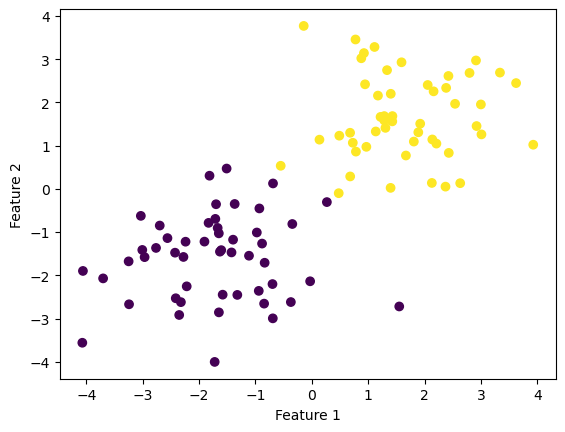

In [17]:
np.random.seed(12345)

n = 100
p_features = 3

X, y = make_blobs(n_samples = 100, n_features = p_features - 1, centers = [(-1.7, -1.7), (1.7, 1.7)])

fig = plt.scatter(X[:,0], X[:,1], c = y)
xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2") 

In [21]:
p = Perceptron()
p.fit(X, y, max_steps = 1000)

print(p.history[-10:])

[0.86, 0.86, 0.86, 0.84, 0.84, 0.81, 0.81, 0.5, 0.83, 0.83]


After implementing my fit function from perceptron.py, I'm able to train my model based on the data. As we can see from the history of accuracy, the accuracy increases to 1. Then I want to draw a separating line and the evolution of the accuracy.

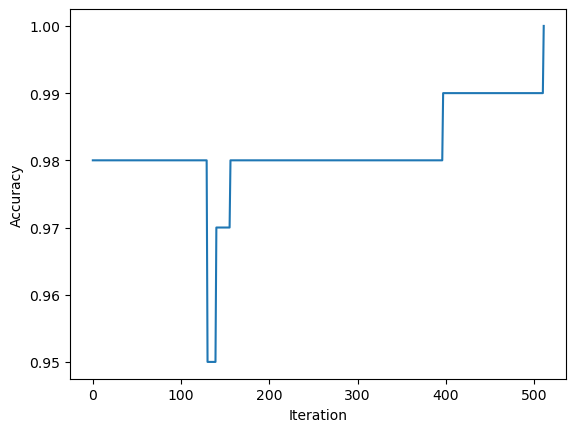

In [15]:
fig = plt.plot(p.history)
xlab = plt.xlabel("Iteration")
ylab = plt.ylabel("Accuracy")

After confirming that my model has 100% accuracy, I want to visualize the linear line from the graph.

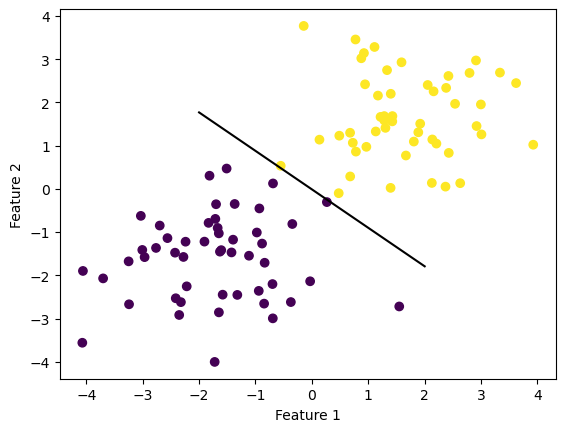

In [11]:
def draw_line(w, x_min, x_max):
  x = np.linspace(x_min, x_max, 101)
  y = -(w[0]*x + w[2])/w[1]
  plt.plot(x, y, color = "black")

fig = plt.scatter(X[:,0], X[:,1], c = y)
fig = draw_line(p.w, -2, 2)

xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2")

## 2

For the second part of my experiment, I'd like to use data that are not linearly separable and draw some visualizations.

[0.86, 0.86, 0.86, 0.86, 0.86, 0.8, 0.8, 0.8, 0.8, 0.8]


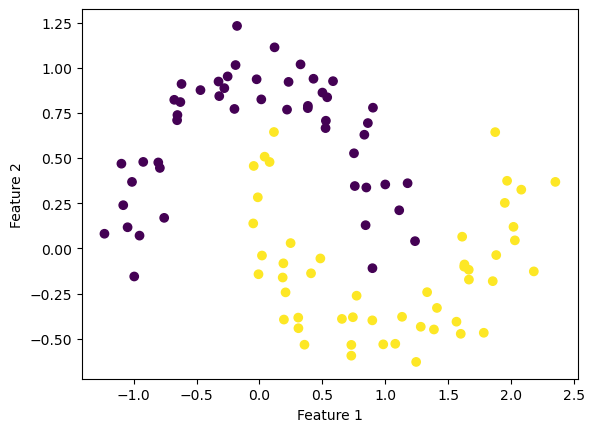

In [23]:
from sklearn.datasets import make_moons

np.random.seed(4)

n = 100

X, y = make_moons(n_samples=100, noise=0.13, random_state=42)

fig = plt.scatter(X[:,0], X[:,1], c = y)
xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2") 

p = Perceptron()
p.fit(X, y, max_steps = 1000)

print(p.history[-10:])

The picture tells us that the data is not linearly seperable, then we want to see how the accuracy performs.

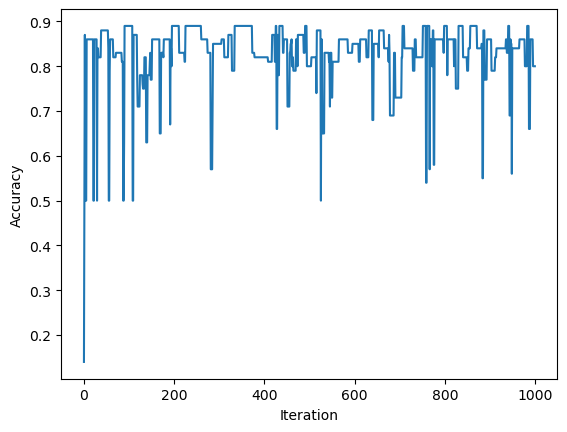

In [24]:
fig = plt.plot(p.history)
xlab = plt.xlabel("Iteration")
ylab = plt.ylabel("Accuracy")

Lastly, the linear separating line also confirmed our previous findings.

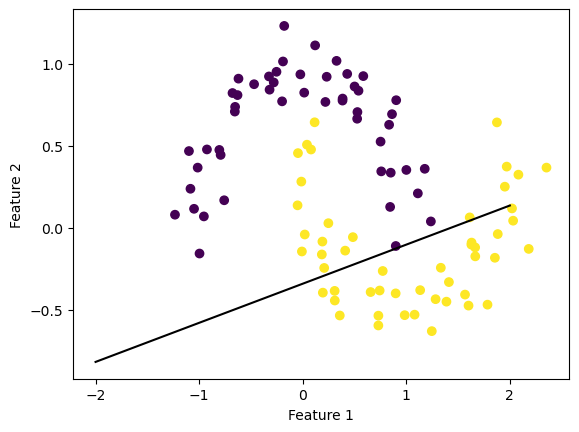

In [25]:
fig = plt.scatter(X[:,0], X[:,1], c = y)
fig = draw_line(p.w, -2, 2)

xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2")

## 3

In part 3, I'd like to show that my algorithm is also able to work in more than 2 dimensions.

[0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 1.0]


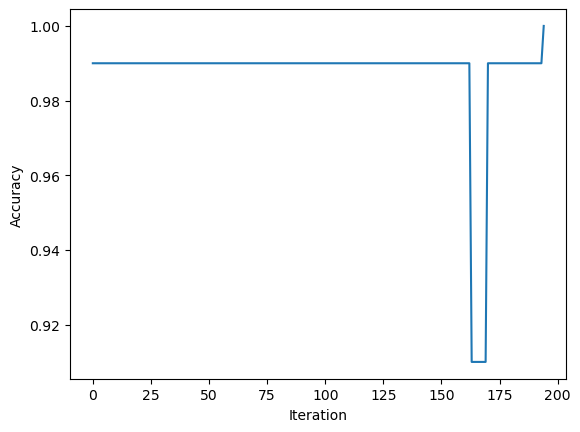

In [28]:
#make some data
np.random.seed(123456)

n = 100
p_features = 5

X, y = make_blobs(n_samples = 100, n_features = p_features - 1, centers = [(-1.7, -1.7), (1.7, 1.7)])

p = Perceptron()
p.fit(X, y, max_steps = 1000)

print(p.history[-10:])

fig = plt.plot(p.history)
xlab = plt.xlabel("Iteration")
ylab = plt.ylabel("Accuracy")

Therefore, according to the evolution of the score over the training period, I believe that the data is linearly separable, because the accuracy has reached 1.

# Additional Questions

_What is the runtime complexity of a single iteration of the perceptron algorithm update as described by Equation 1? Assume that the relevant operations are addition and multiplication. Does the runtime complexity depend on the number of data points? What about the number of features?_

I think the runtime complexity will depend more on the number of features instead of number of data points. Because recall from our previous fit function, we only need to consider one single point in doing the weight updating. Therefore, the number of data points won't affect the time complexity. However, when we uppdate the weight, we are performing the matrix multiplication on every feature. Thus, increasing the number of features will largely make the computation harder and more time consuming.

